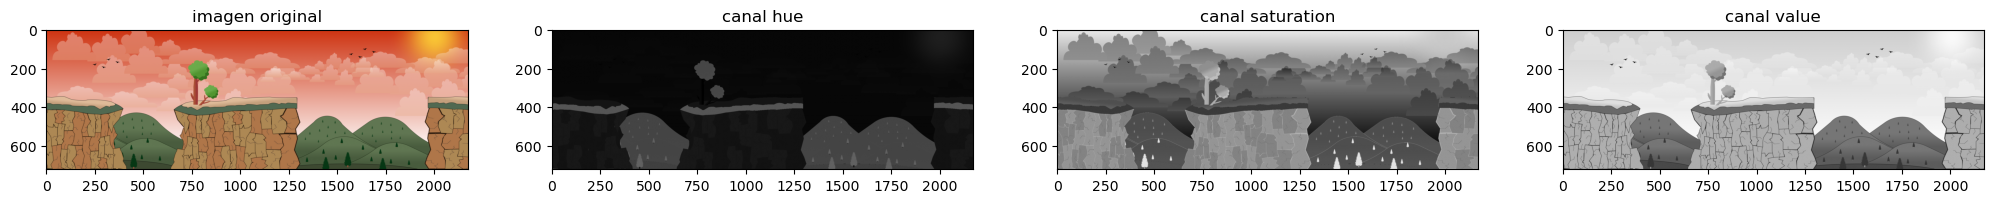

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
imagen1=cv2.imread('v4033_197.png')
img=cv2.cvtColor(imagen1, cv2.COLOR_BGR2RGB)
def RGB2HSV(img):
    img=img.astype('float32')
    img=img/255
    new_img=np.zeros_like(img)

    maxChanel=np.argmax(img, axis=2)
    maxValue=np.amax(img, axis=2)
    minChanel=np.argmin(img, axis=2)
    minValue=np.amin(img, axis=2)
    # calculo de value

    new_img[:,:,2]=maxValue
    # calculo de saturation

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j]==0:
                new_img[i,j,1]=0
            elif maxValue[i,j]!=0:
                new_img[i,j,1]=(new_img[i,j,2]-minValue[i,j])/new_img[i,j,2]
    

    # calculo de hue
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            # Si max == min (imagen en escala de grises), hue = 0
            if maxValue[i,j]==minValue[i,j]:
                new_img[i,j,0]=0
            elif maxChanel[i,j]==0:  # Canal rojo es el máximo
                new_img[i,j,0]=60*((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))
            elif maxChanel[i,j]==1:  # Canal verde es el máximo
                new_img[i,j,0]=120+60*(img[i,j,2]-img[i,j,0])/(new_img[i,j,2]-minValue[i,j])
            elif maxChanel[i,j]==2:  # Canal azul es el máximo
                new_img[i,j,0]=240+60*(img[i,j,0]-img[i,j,1])/(new_img[i,j,2]-minValue[i,j])
        img2=new_img[...,0]<0  # Corregido: usar corchetes en lugar de paréntesis
        new_img[img2,0]=new_img[img2,0]+360
    return new_img

hsv_img=RGB2HSV(img)
fig,axs=plt.subplots(1,4, figsize=(25,10))
axs[0].imshow(img)
axs[0].set_title('imagen original')
fig_img=axs[1].imshow(hsv_img[...,0], cmap='gray', vmin=0, vmax=360)
axs[1].set_title('canal hue')

fig_img=axs[2].imshow(hsv_img[...,1], cmap='gray', vmin=0, vmax=1)
axs[2].set_title('canal saturation')

fig_img=axs[3].imshow(hsv_img[...,2], cmap='gray', vmin=0, vmax=1)  # Corregido: vmax=1
axs[3].set_title('canal value')
plt.show()

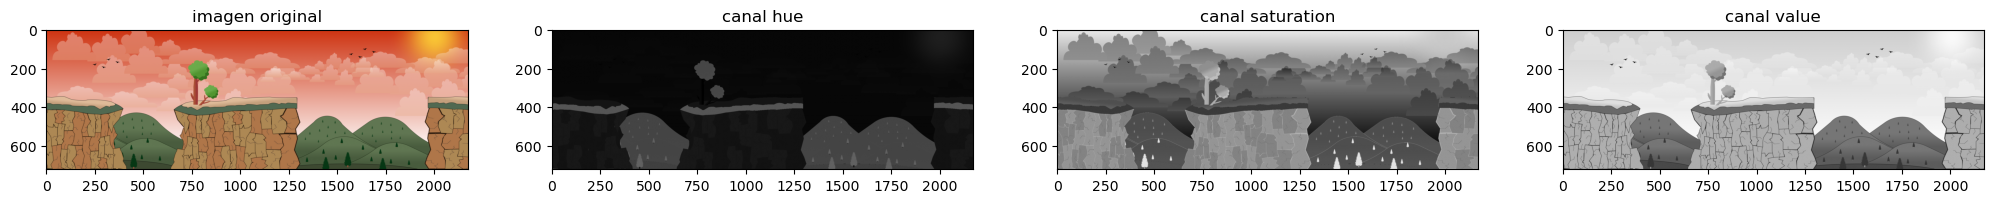

In [3]:
hsv_img_opencv=cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
fig,axs=plt.subplots(1,4, figsize=(25,10))
axs[0].imshow(img)
axs[0].set_title('imagen original')
fig_img=axs[1].imshow(hsv_img[...,0], cmap='gray', vmin=0, vmax=360)
axs[1].set_title('canal hue')

fig_img=axs[2].imshow(hsv_img[...,1], cmap='gray', vmin=0, vmax=1)
axs[2].set_title('canal saturation')

fig_img=axs[3].imshow(hsv_img[...,2], cmap='gray', vmin=0, vmax=1)  # Corregido: vmax=1
axs[3].set_title('canal value')
plt.show()

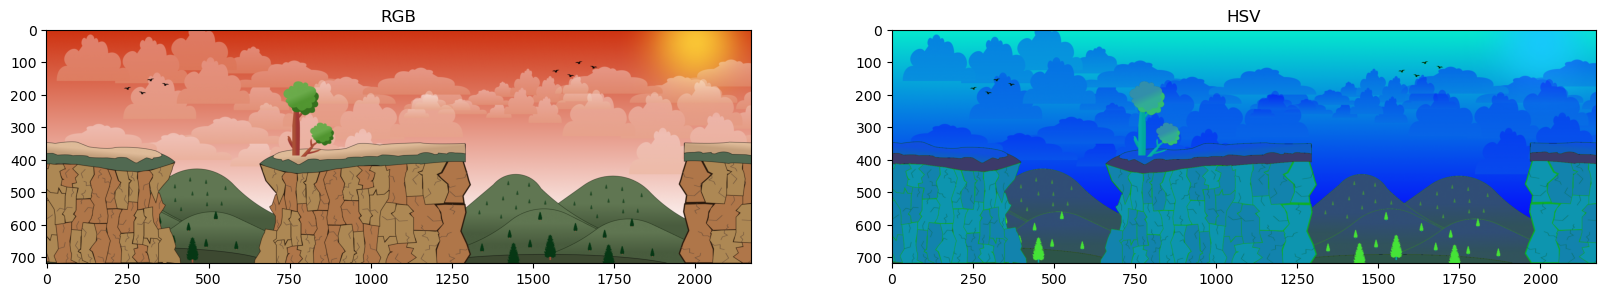

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_rgb = cv2.cvtColor(cv2.imread('v4033_197.png', cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].imshow(img_rgb)
axs[0].set_title('RGB')
axs[1].imshow(img_hsv)
axs[1].set_title('HSV')
img_hsv_bgr = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2BGR)
plt.imsave('imagen_hsv.png', img_hsv)


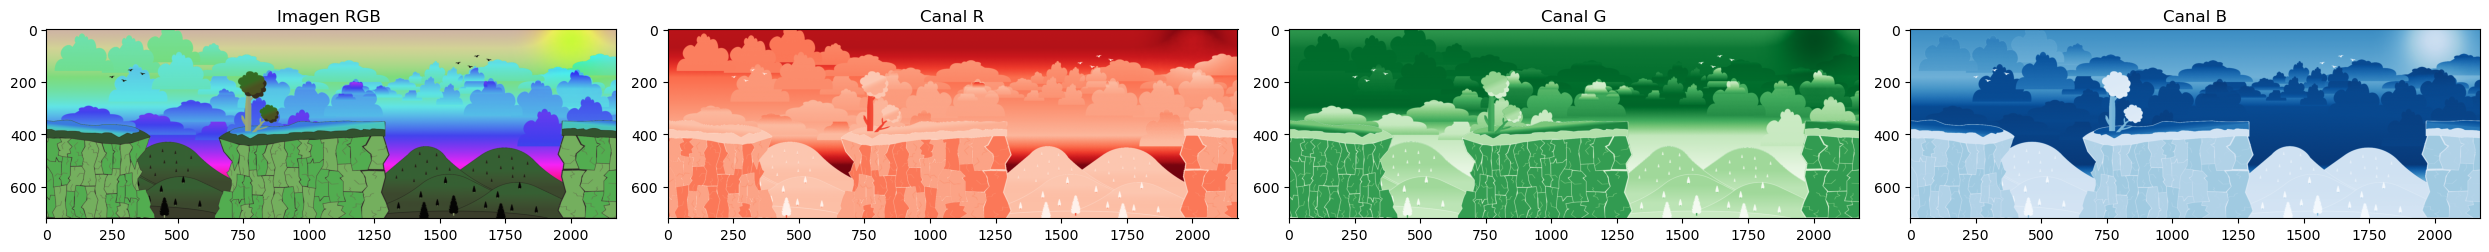

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def HSV2RGB(hsv_img):
    H = hsv_img[:, :, 0].astype('float32')
    S = hsv_img[:, :, 1].astype('float32')
    V = hsv_img[:, :, 2].astype('float32')

    C = V * S
    X = C * (1 - np.abs((H / 60.0) % 2 - 1))
    m = V - C

    R_prime = np.zeros_like(H)
    G_prime = np.zeros_like(H)
    B_prime = np.zeros_like(H)

    mask0 = (H >= 0)   & (H < 60);  R_prime[mask0] = C[mask0]; G_prime[mask0] = X[mask0]
    mask1 = (H >= 60)  & (H < 120); R_prime[mask1] = X[mask1]; G_prime[mask1] = C[mask1]
    mask2 = (H >= 120) & (H < 180); G_prime[mask2] = C[mask2]; B_prime[mask2] = X[mask2]
    mask3 = (H >= 180) & (H < 240); G_prime[mask3] = X[mask3]; B_prime[mask3] = C[mask3]
    mask4 = (H >= 240) & (H < 300); R_prime[mask4] = X[mask4]; B_prime[mask4] = C[mask4]
    mask5 = (H >= 300) & (H < 360); R_prime[mask5] = C[mask5]; B_prime[mask5] = X[mask5]

    rgb = np.stack([
        (R_prime + m) * 255,
        (G_prime + m) * 255,
        (B_prime + m) * 255
    ], axis=2)

    return np.clip(rgb, 0, 255).astype('uint8')


raw = cv2.imread('v4033_197.png')

hsv_cargada = np.zeros(raw.shape, dtype='float32')
hsv_cargada[:, :, 0] = raw[:, :, 0].astype('float32') / 255.0 * 360
hsv_cargada[:, :, 1] = raw[:, :, 1].astype('float32') / 255.0
hsv_cargada[:, :, 2] = raw[:, :, 2].astype('float32') / 255.0

rgb_resultado = HSV2RGB(hsv_cargada)

fig, axs = plt.subplots(1, 4, figsize=(25, 10))

axs[0].imshow(rgb_resultado)
axs[0].set_title('Imagen RGB ')

axs[1].imshow(rgb_resultado[:, :, 0], cmap='Reds', vmin=0, vmax=255)
axs[1].set_title('Canal R')

axs[2].imshow(rgb_resultado[:, :, 1], cmap='Greens', vmin=0, vmax=255)
axs[2].set_title('Canal G')

axs[3].imshow(rgb_resultado[:, :, 2], cmap='Blues', vmin=0, vmax=255)
axs[3].set_title('Canal B')

plt.tight_layout()
plt.show()
